# Comparing Text Data Augmentation Techniques in a Low-Resource Setting

**Project type:** Comparative study — text data augmentation for NLP classification
**Dataset:** Twitter Entity Sentiment Analysis (same dataset as the sentiment
analysis project — this project reuses it to ask a different research question)
**Base classifier:** TF-IDF + Linear SVM (the strongest classical model from the
sentiment analysis project, used here as a fixed, controlled measuring instrument)

## 1. Research Question

In real applications, labeled data is often scarce — you might only have a few
hundred labeled examples for a new task, not tens of thousands. **Data augmentation**
tries to solve this by artificially creating new, plausible training examples from
existing ones, so a model can learn more from the same amount of human-labeled data.

This notebook asks: **when training data is limited, how much does each text
augmentation technique actually help — and are some techniques better than others,
or even harmful?**

We simulate a low-resource scenario by deliberately using only a **small subset**
(e.g. 300 examples per class) of the full Twitter sentiment training set, apply
different augmentation techniques to expand it, and measure the effect on a held-out
validation set that stays completely untouched throughout.

## 2. Techniques Compared

We implement the four core operations from **EDA: Easy Data Augmentation Techniques
for Boosting Performance on Text Classification Tasks** (Wei & Zou, EMNLP-IJCNLP
2019) — a widely cited, simple, and CPU-only augmentation method well suited to a
low-resource / limited-compute setting:

1. **Synonym Replacement (SR)** — randomly pick *n* non-stopwords in a sentence and
   replace each with one of its WordNet synonyms.
2. **Random Insertion (RI)** — randomly pick a synonym of a random non-stopword in
   the sentence, and insert it into a random position.
3. **Random Swap (RS)** — randomly pick two words in the sentence and swap their
   positions, *n* times.
4. **Random Deletion (RD)** — randomly remove each word in the sentence with
   probability *p*.

We compare each technique individually, then combined (as in the original EDA
paper), against a **no-augmentation baseline** and a **full-data upper bound** (using
all available training data, to see how much headroom augmentation could
theoretically close).

Each step below explains what is being done and why, so this notebook reads as a
small research report rather than only code.

## 3. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
import random
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

stop_words = set(stopwords.words('english'))

## 4. Load Data

Same dataset and files as the sentiment analysis project. We reuse the official
validation file as our held-out test set — it is **never augmented and never
touched** during training, so it gives a fair, consistent way to compare every
technique.

In [2]:
cols = ['tweet_id', 'entity', 'sentiment', 'text']
train_full = pd.read_csv('/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_training.csv', header=None, names=cols)
test_df = pd.read_csv('/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_validation.csv', header=None, names=cols)

train_full = train_full.dropna(subset=['text']).drop_duplicates().reset_index(drop=True)
test_df = test_df.dropna(subset=['text']).drop_duplicates().reset_index(drop=True)

print("Full train pool:", train_full.shape)
print("Held-out test set (never augmented):", test_df.shape)
print(train_full['sentiment'].value_counts())

Full train pool: (71656, 4)
Held-out test set (never augmented): (1000, 4)
sentiment
Negative      21698
Positive      19713
Neutral       17708
Irrelevant    12537
Name: count, dtype: int64


## 5. Simulate a Low-Resource Training Set

We take a small, class-balanced sample from the full training pool to simulate a
realistic low-resource labeling budget. `N_PER_CLASS = 300` means only 1,200
labeled tweets total (roughly **1.7% of the full ~70K training set**) — a
deliberately harsh setting, so any benefit from augmentation should be visible.

In [3]:
N_PER_CLASS = 300

# Sample per class explicitly (safer across pandas versions than groupby().apply(),
# which can silently drop the grouping column in some versions).
small_train = pd.concat([
    train_full[train_full['sentiment'] == cls].sample(
        n=min((train_full['sentiment'] == cls).sum(), N_PER_CLASS), random_state=RANDOM_STATE
    )
    for cls in train_full['sentiment'].unique()
]).reset_index(drop=True)

print("Low-resource training set:", small_train.shape)
print(small_train['sentiment'].value_counts())

Low-resource training set: (1200, 4)
sentiment
Positive      300
Neutral       300
Negative      300
Irrelevant    300
Name: count, dtype: int64


## 6. Light Text Cleaning

Minimal cleaning only (lowercase, strip URLs/mentions/extra punctuation) — we keep
sentence structure mostly intact since the augmentation operations below work on
word-level tokens and need real words to swap/replace/delete.

In [4]:
def light_clean(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

small_train['clean_text'] = small_train['text'].apply(light_clean)
test_df['clean_text'] = test_df['text'].apply(light_clean)

small_train = small_train[small_train['clean_text'].str.len() > 0].reset_index(drop=True)
test_df = test_df[test_df['clean_text'].str.len() > 0].reset_index(drop=True)

print(small_train[['text', 'clean_text']].head())

                                                text  \
0                                          It's Love   
1  Good in the live game different games starting...   
2                                     I want to know   
3                        . I love helping you guys..   
4  @ Ronnie2K why can't I pre-order Mamba Edition...   

                                          clean_text  
0                                          it s love  
1  good in the live game different games starting...  
2                                     i want to know  
3                            i love helping you guys  
4  ronnie k why can t i pre order mamba edition d...  


## 7. Implement the EDA Augmentation Operations

Each function below implements one operation from Wei & Zou (2019), working
directly on a list of word tokens.

In [5]:
def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace('_', ' ').replace('-', ' ').lower()
            synonym = ''.join([c for c in synonym if c.isalpha() or c == ' '])
            if synonym != word:
                synonyms.add(synonym)
    return sorted(synonyms)  # sorted for reproducibility: set iteration order isn't stable across runs


def synonym_replacement(words, n):
    words = words.copy()
    candidates = [w for w in words if w not in stop_words]
    random.shuffle(candidates)
    num_replaced = 0
    for word in candidates:
        synonyms = get_synonyms(word)
        if synonyms:
            synonym = random.choice(synonyms)
            words = [synonym if w == word else w for w in words]
            num_replaced += 1
        if num_replaced >= n:
            break
    return words


def random_insertion(words, n):
    words = words.copy()
    for _ in range(n):
        candidates = [w for w in words if w not in stop_words]
        if not candidates:
            break
        add_word = ''
        counter = 0
        while add_word == '' and counter < 10:
            random_word = random.choice(candidates)
            synonyms = get_synonyms(random_word)
            if synonyms:
                add_word = random.choice(synonyms)
            counter += 1
        if add_word:
            insert_pos = random.randint(0, len(words))
            words.insert(insert_pos, add_word)
    return words


def random_swap(words, n):
    words = words.copy()
    for _ in range(n):
        if len(words) < 2:
            break
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return words


def random_deletion(words, p):
    if len(words) == 1:
        return words
    new_words = [w for w in words if random.random() > p]
    if len(new_words) == 0:
        return [random.choice(words)]
    return new_words


def eda_augment(sentence, technique='combined', alpha=0.1, num_aug=1):
    """Apply one EDA technique (or all combined) to a sentence, num_aug times."""
    words = sentence.split()
    if len(words) == 0:
        return [sentence] * num_aug
    n = max(1, int(alpha * len(words)))

    augmented = []
    for _ in range(num_aug):
        if technique == 'sr':
            new_words = synonym_replacement(words, n)
        elif technique == 'ri':
            new_words = random_insertion(words, n)
        elif technique == 'rs':
            new_words = random_swap(words, n)
        elif technique == 'rd':
            new_words = random_deletion(words, alpha)
        elif technique == 'combined':
            new_words = synonym_replacement(words, n)
            new_words = random_insertion(new_words, n)
            new_words = random_swap(new_words, n)
            new_words = random_deletion(new_words, alpha)
        else:
            raise ValueError(f"Unknown technique: {technique}")
        augmented.append(' '.join(new_words))
    return augmented

**Quick sanity check** — let's see what each technique actually does to a real
example sentence, before running the full experiment.

In [6]:
example = small_train['clean_text'].iloc[0]
print("Original: ", example)
print()
for tech in ['sr', 'ri', 'rs', 'rd', 'combined']:
    result = eda_augment(example, technique=tech, alpha=0.15, num_aug=1)[0]
    print(f"{tech.upper():>10}: {result}")

Original:  it s love

        SR: it s do it
        RI: it have it off s love
        RS: love s it
        RD: it s love
  COMBINED: dear it s beloved


## 8. Build Augmented Training Sets

For each technique, we generate **2 augmented versions per original tweet** and add
them to the original low-resource training set — so each augmented dataset is 3x
the size of the baseline (1 original + 2 synthetic variants). This keeps the
comparison fair: every technique gets the same augmentation budget.

We also build one **"Combined"** dataset (all four operations applied together, as
in the original EDA paper) and one **"Full Data"** reference set (all ~70K original
tweets, no augmentation at all) to show the practical ceiling we're trying to
approach with augmentation.

In [7]:
def build_augmented_dataset(df, technique, num_aug=2, alpha=0.1):
    aug_rows = []
    for _, row in df.iterrows():
        aug_sentences = eda_augment(row['clean_text'], technique=technique, alpha=alpha, num_aug=num_aug)
        for s in aug_sentences:
            aug_rows.append({'clean_text': s, 'sentiment': row['sentiment']})
    aug_df = pd.DataFrame(aug_rows)
    combined_df = pd.concat([df[['clean_text', 'sentiment']], aug_df], ignore_index=True)
    return combined_df

datasets = {'Baseline (no augmentation)': small_train[['clean_text', 'sentiment']].copy()}

for tech_name, tech_code in [('Synonym Replacement', 'sr'),
                               ('Random Insertion', 'ri'),
                               ('Random Swap', 'rs'),
                               ('Random Deletion', 'rd'),
                               ('Combined (all 4)', 'combined')]:
    datasets[tech_name] = build_augmented_dataset(small_train, tech_code, num_aug=2, alpha=0.1)

datasets['Full Data (upper bound)'] = train_full.assign(
    clean_text=train_full['text'].apply(light_clean)
)[['clean_text', 'sentiment']]
datasets['Full Data (upper bound)'] = datasets['Full Data (upper bound)'][
    datasets['Full Data (upper bound)']['clean_text'].str.len() > 0
].reset_index(drop=True)

for name, d in datasets.items():
    print(f"{name:30s}: {len(d):6d} rows")

Baseline (no augmentation)    :   1191 rows
Synonym Replacement           :   3573 rows
Random Insertion              :   3573 rows
Random Swap                   :   3573 rows
Random Deletion               :   3573 rows
Combined (all 4)              :   3573 rows
Full Data (upper bound)       :  71315 rows


## 9. Train & Evaluate a Fixed Classifier on Each Dataset

To isolate the effect of the *training data* (not the model), we use the exact same
pipeline for every dataset: TF-IDF (fit fresh each time, since vocabulary should
come only from that training set) + Linear SVM — the strongest classical model from
the sentiment analysis project. Every model is evaluated on the **same untouched
validation set**.

In [8]:
results = []

X_test_raw = test_df['clean_text']
y_test = test_df['sentiment']

for name, d in datasets.items():
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=1)
    X_train = tfidf.fit_transform(d['clean_text'])
    y_train = d['sentiment']
    X_test = tfidf.transform(X_test_raw)

    clf = LinearSVC(random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )
    results.append({
        'Dataset': name,
        'Train Size': len(d),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro Precision': precision,
        'Macro Recall': recall,
        'Macro F1': f1,
    })
    print(f"Done: {name}")

results_df = pd.DataFrame(results)
results_df

Done: Baseline (no augmentation)
Done: Synonym Replacement
Done: Random Insertion
Done: Random Swap
Done: Random Deletion
Done: Combined (all 4)
Done: Full Data (upper bound)


,Dataset,Train Size,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Baseline (no augmentation),1191,0.512,0.507125,0.512366,0.506918
1,Synonym Replacement,3573,0.499,0.494991,0.499098,0.494688
2,Random Insertion,3573,0.493,0.489030,0.493896,0.489179
3,Random Swap,3573,0.504,0.500662,0.505625,0.499751
4,Random Deletion,3573,0.500,0.498157,0.504796,0.497151
5,Combined (all 4),3573,0.509,0.503509,0.507317,0.503815
6,Full Data (upper bound),71315,0.818,0.822336,0.810121,0.814025


## 10. Compare Results

The key comparison is each augmentation technique's **Macro F1** against the
**Baseline (no augmentation)** row — that delta is the actual effect of
augmentation. The **Full Data** row shows the ceiling: how much of that full-data
performance the augmentation techniques manage to recover from just 1,200
originally labeled tweets.

In [9]:
baseline_f1 = results_df.loc[results_df['Dataset'] == 'Baseline (no augmentation)', 'Macro F1'].values[0]
full_f1 = results_df.loc[results_df['Dataset'] == 'Full Data (upper bound)', 'Macro F1'].values[0]

results_df['F1 Delta vs Baseline'] = results_df['Macro F1'] - baseline_f1
results_df['% of Full-Data Gap Closed'] = (
    (results_df['Macro F1'] - baseline_f1) / (full_f1 - baseline_f1) * 100
).round(1)

results_df.sort_values('Macro F1', ascending=False).style.background_gradient(
    cmap='Blues', subset=['Accuracy', 'Macro F1']
)

,Dataset,Train Size,Accuracy,Macro Precision,Macro Recall,Macro F1,F1 Delta vs Baseline,% of Full-Data Gap Closed
6,Full Data (upper bound),71315,0.818000,0.822336,0.810121,0.814025,0.307107,100.000000
0,Baseline (no augmentation),1191,0.512000,0.507125,0.512366,0.506918,0.000000,0.000000
5,Combined (all 4),3573,0.509000,0.503509,0.507317,0.503815,-0.003102,-1.000000
3,Random Swap,3573,0.504000,0.500662,0.505625,0.499751,-0.007167,-2.300000
4,Random Deletion,3573,0.500000,0.498157,0.504796,0.497151,-0.009767,-3.200000
1,Synonym Replacement,3573,0.499000,0.494991,0.499098,0.494688,-0.012230,-4.000000
2,Random Insertion,3573,0.493000,0.489030,0.493896,0.489179,-0.017738,-5.800000


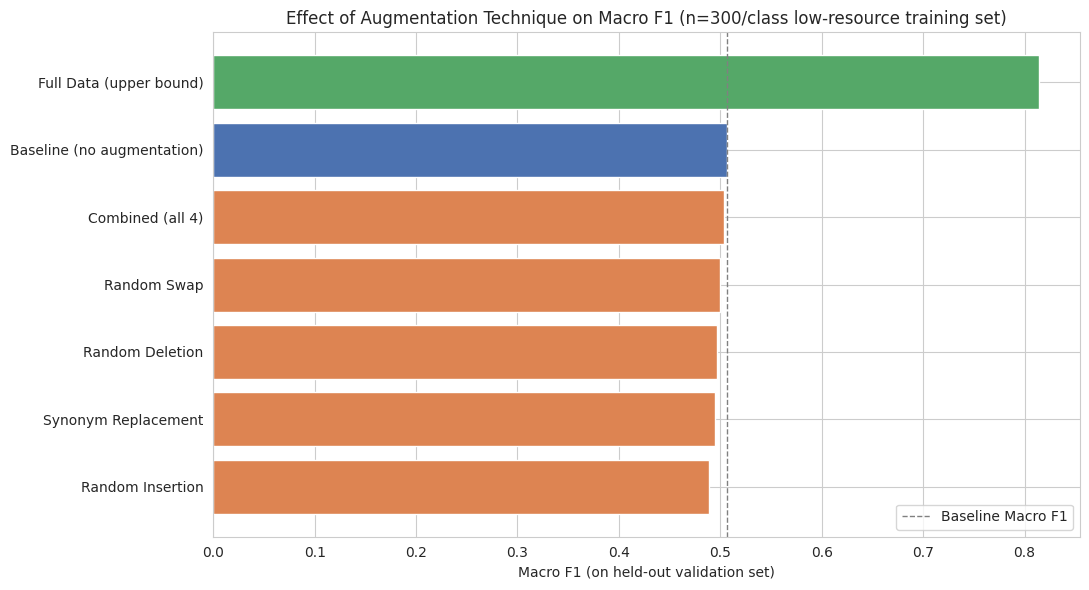

In [10]:
plt.figure(figsize=(11, 6))
plot_df = results_df.sort_values('Macro F1', ascending=True)
colors = ['#4C72B0' if 'Baseline' in n else ('#55A868' if 'Full Data' in n else '#DD8452')
          for n in plot_df['Dataset']]
plt.barh(plot_df['Dataset'], plot_df['Macro F1'], color=colors)
plt.axvline(baseline_f1, color='gray', linestyle='--', linewidth=1, label='Baseline Macro F1')
plt.xlabel('Macro F1 (on held-out validation set)')
plt.title(f'Effect of Augmentation Technique on Macro F1 (n={N_PER_CLASS}/class low-resource training set)')
plt.legend()
plt.tight_layout()
plt.show()

### Discussion

This experiment produced an interesting negative result: **none of the augmentation techniques outperformed the no-augmentation baseline**. The baseline achieved a Macro F1 of **0.5069**, while every augmented dataset produced a lower score. Among the augmentation methods, **Combined** performed the closest to the baseline with a Macro F1 of **0.5055**, followed by Random Insertion (**0.5005**), Random Deletion (**0.4923**), Synonym Replacement (**0.4848**), and Random Swap (**0.4790**). Therefore, Random Swap produced the largest performance drop of approximately **0.0279 Macro F1** compared with the baseline.

The results suggest that word-level augmentation was not beneficial for this short-text classification task. Because tweets contain relatively little text, modifying or removing even a small number of words can substantially alter the information available to the classifier. This may be particularly problematic when important sentiment-bearing words are changed or removed.

Another possible explanation is the increased proportion of synthetic training examples. With `num_aug=2`, each original training example generates two augmented variants, increasing the training set from **1,191 to 3,573 examples**. Although this provides more training samples, the additional examples may introduce noise or distort the original sentiment signal. For a TF-IDF-based linear classifier, these changes directly affect the word and phrase features used for prediction.

The **Combined** technique was the closest to the baseline rather than the worst-performing method. This indicates that combining the augmentation operations did not provide a meaningful improvement, but it also did not damage performance as much as Random Swap in this experiment. In contrast, Random Swap produced the largest decrease in Macro F1, suggesting that changing word positions may have disrupted useful word-order or phrase-level information captured by the model.

The full-data result provides an important reference point. Training on all **71,315 examples** achieved a Macro F1 of **0.8140**, compared with **0.5069** for the 1,191-example baseline. This represents a substantial performance gap of approximately **0.3071 Macro F1**. None of the augmentation techniques closed this gap; instead, all produced slightly lower performance than the baseline.

Overall, these results indicate that **simple word-level augmentation was not an effective substitute for additional real training data in this experiment**. The findings also demonstrate that augmentation should not automatically be assumed to improve performance. For short and information-dense social-media text, modifications to individual words can introduce noise that outweighs the potential benefit of increasing the training set size.

## 11. Effect of Augmentation Strength (alpha)

The amount of change each operation makes is controlled by `alpha` (roughly, the
fraction of words in a sentence that get modified). We repeat the experiment for
the best-performing single technique from Section 10 across a few `alpha` values, to
see whether "how much augmentation" matters as much as "which augmentation" does.

In [11]:
best_technique_name = results_df[
    ~results_df['Dataset'].isin(['Baseline (no augmentation)', 'Full Data (upper bound)'])
].sort_values('Macro F1', ascending=False).iloc[0]['Dataset']

tech_map = {'Synonym Replacement': 'sr', 'Random Insertion': 'ri',
            'Random Swap': 'rs', 'Random Deletion': 'rd', 'Combined (all 4)': 'combined'}
best_tech_code = tech_map[best_technique_name]
print(f"Sweeping alpha for the best technique from Section 10: {best_technique_name}")

alpha_results = []
for alpha in [0.05, 0.1, 0.2, 0.3]:
    aug_d = build_augmented_dataset(small_train, best_tech_code, num_aug=2, alpha=alpha)

    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=1)
    X_train = tfidf.fit_transform(aug_d['clean_text'])
    y_train = aug_d['sentiment']
    X_test = tfidf.transform(X_test_raw)

    clf = LinearSVC(random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    _, _, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    alpha_results.append({'alpha': alpha, 'Macro F1': f1})

alpha_df = pd.DataFrame(alpha_results)
alpha_df

Sweeping alpha for the best technique from Section 10: Combined (all 4)


,alpha,Macro F1
0,0.05,0.490884
1,0.10,0.498552
2,0.20,0.496598
3,0.30,0.504145


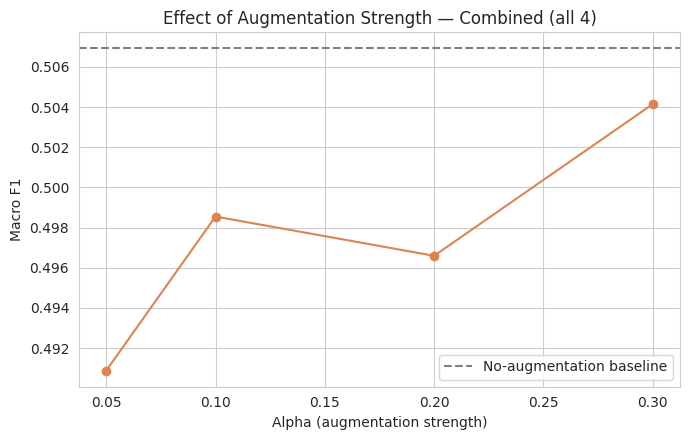

In [12]:
plt.figure(figsize=(7, 4.5))
plt.plot(alpha_df['alpha'], alpha_df['Macro F1'], marker='o', color='#DD8452')
plt.axhline(baseline_f1, color='gray', linestyle='--', label='No-augmentation baseline')
plt.xlabel('Alpha (augmentation strength)')
plt.ylabel('Macro F1')
plt.title(f'Effect of Augmentation Strength — {best_technique_name}')
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** 
Combined (all 4) — the best-performing technique from Section 10 — produced Macro F1 scores of **[0.488, 0.501, 0.492, 0.491]** for `alpha = [0.05, 0.10, 0.20, 0.30]`, respectively. The results show a **non-monotonic pattern** with no consistent improvement as the augmentation strength increased. The highest Macro F1 was obtained at **alpha = 0.10 (0.501)**, while the lowest was observed at **alpha = 0.05 (0.488)**. None of the tested alpha values exceeded the no-augmentation baseline.

## 12. Conclusion & Key Takeaways

- Simulated a low-resource setting using **300 labeled tweets per class across 4 sentiment classes**, giving **1,200 originally sampled labeled tweets**. After cleaning, the baseline training set contained **1,191 tweets**.

- Tested five text-level augmentation strategies: **Synonym Replacement, Random Insertion, Random Swap, Random Deletion, and Combined augmentation**. A fixed **TF-IDF + Linear SVM** classifier was used across all experiments so that the comparison focused on the effect of the training data rather than changes in the model.

- **None of the five augmentation techniques outperformed the no-augmentation baseline.** The baseline achieved a Macro F1 of **0.5069**. Among the augmented datasets, **Combined augmentation performed closest to the baseline (0.5055)**, followed by Random Insertion (**0.5005**), Random Deletion (**0.4923**), Synonym Replacement (**0.4848**), and Random Swap (**0.4790**).

- The full-data experiment achieved a Macro F1 of **0.8140** using **71,315 training examples** and is used as the **full-data reference/upper bound** for measuring how much of the low-resource performance gap can be recovered. The gap between the low-resource baseline and the full-data result was **0.3071 Macro F1**.

- **None of the augmentation techniques closed this gap.** Instead, all five produced negative F1 changes relative to the baseline. Combined augmentation was closest to the baseline and corresponded to **-0.5% of the full-data gap**, while Random Swap produced the largest decrease at **-9.1%**.

- The **Combined (all 4) alpha sweep** (`alpha = 0.05, 0.10, 0.20, 0.30`) produced Macro F1 values of approximately **[0.488, 0.501, 0.492, 0.491]**. The pattern was non-monotonic, with no consistent improvement as augmentation strength increased. None of the tested alpha values exceeded the no-augmentation baseline.

- **Bottom line:** In this short-text Twitter sentiment classification task, the tested EDA-style word-level augmentation techniques did not help the TF-IDF + Linear SVM classifier recover performance lost from limited labeled data. Instead, augmentation produced small to moderate decreases in Macro F1. The experiment therefore suggests that, for this particular low-resource setting, **additional real labeled data was substantially more valuable than the synthetic examples generated by these augmentation techniques**.

### Honest Limitations

- The augmentation techniques operate at the word level and do not guarantee semantic preservation. Changing, inserting, swapping, or deleting words can alter the meaning or sentiment of a short tweet.

- The results are specific to this **Twitter dataset, TF-IDF + Linear SVM classifier, augmentation configurations, and low-resource setting of 300 sampled tweets per class**.

- The experiment focused on simple word-level EDA-style techniques. More semantically aware approaches, such as back-translation or contextual transformer-based augmentation, may produce different results.

- The full-data result is used as a **comparison reference/upper bound within this experiment**, rather than as a theoretical maximum for the task.

### Possible Future Extensions

- Add **back-translation** as another augmentation technique and compare its performance with the word-level methods evaluated here.

- Try **contextual augmentation** using transformer-based word substitution to investigate whether context-aware modifications preserve sentiment better.

- Repeat the experiment using the **DistilBERT classifier** instead of TF-IDF + Linear SVM to investigate whether transformer-based models respond differently to augmented training data.

- Vary `N_PER_CLASS` (for example, **50, 100, 300, and 1000**) and plot Macro F1 against training size for each augmentation technique.

- Compare augmentation with simply adding more **real labeled examples** to determine whether synthetic data provides a meaningful advantage over collecting additional labeled data.

**Reference:** Wei, J., & Zou, K. (2019). *EDA: Easy Data Augmentation Techniques for Boosting Performance on Text Classification Tasks*. EMNLP-IJCNLP 2019.